In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## Loading the dataset

In [3]:
df = pd.read_csv(r'IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## Basic Information

In [308]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [309]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]} ")

your rows are 74 and your columns are 20 


## Basic Questions 

### **1. which team won most matches**

Gujarat


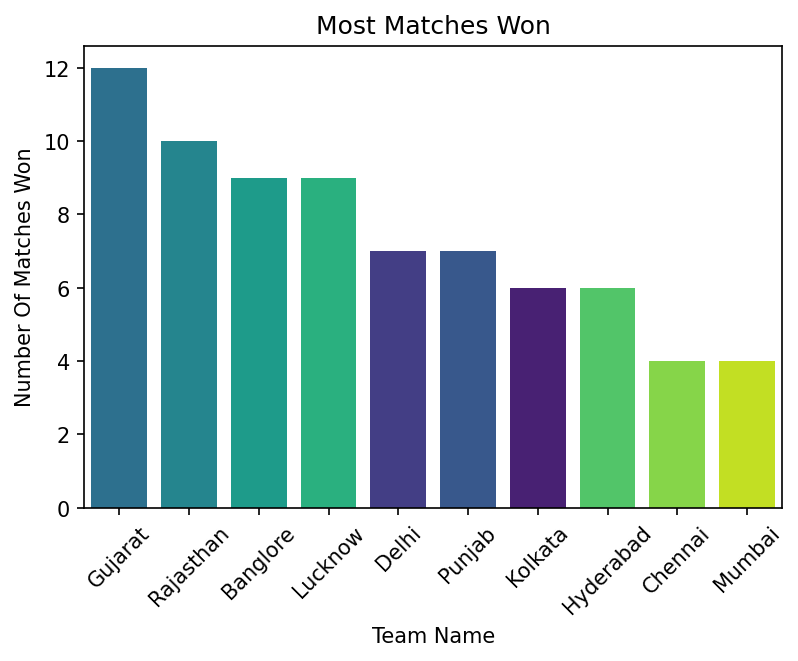

In [133]:
print(df['match_winner'].value_counts().index[0])
figure = plt.figure(figsize=[6,4],dpi=150)
most_win = df['match_winner'].value_counts()
plt.xticks(rotation=45)

sns.countplot(df,x="match_winner",order=df['match_winner'].value_counts().index,palette='viridis',saturation=1,hue="match_winner")
plt.title("Most Matches Won")
plt.xlabel("Team Name")
plt.ylabel("Number Of Matches Won")
plt.show()

### **2.Toss Decisions Trend**

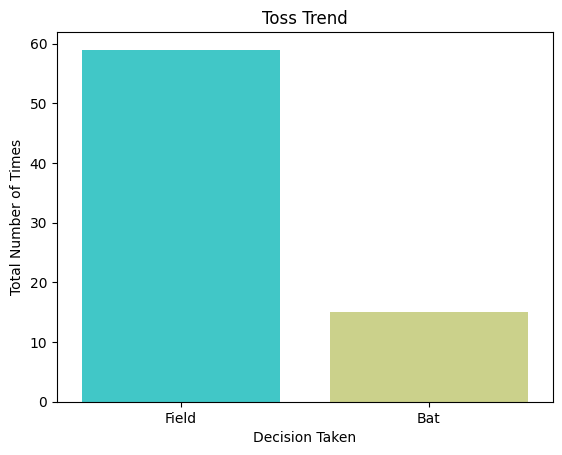

In [139]:
sns.countplot(x=df['toss_decision'],palette="rainbow",hue=df["toss_decision"])
plt.xlabel("Decision Taken")
plt.ylabel("Total Number of Times")
plt.title("Toss Trend")
plt.show()


### **3.Toss Winner Vs Match Winner**

In [324]:
toss_winner_match = df[df['toss_winner']==df['match_winner']]
print("Percentage of matches won by team winning toss")
(toss_winner_match.shape[0]/df.shape[0])*100

Percentage of matches won by team winning toss


48.64864864864865

## **4.How do Teams win wicket vs runs**

In [143]:
print(df['won_by'].value_counts())
sns.countplot(x= df['won_by'],palette="rainbow",hue=df['won_by'])
plt.title("Winning Type")
plt.xlabel("Won By")
plt.ylabel("Number of Times")

IndentationError: unexpected indent (3849032056.py, line 6)

## **5.Most Player of The Match Analysis**

Kuldeep Yadav


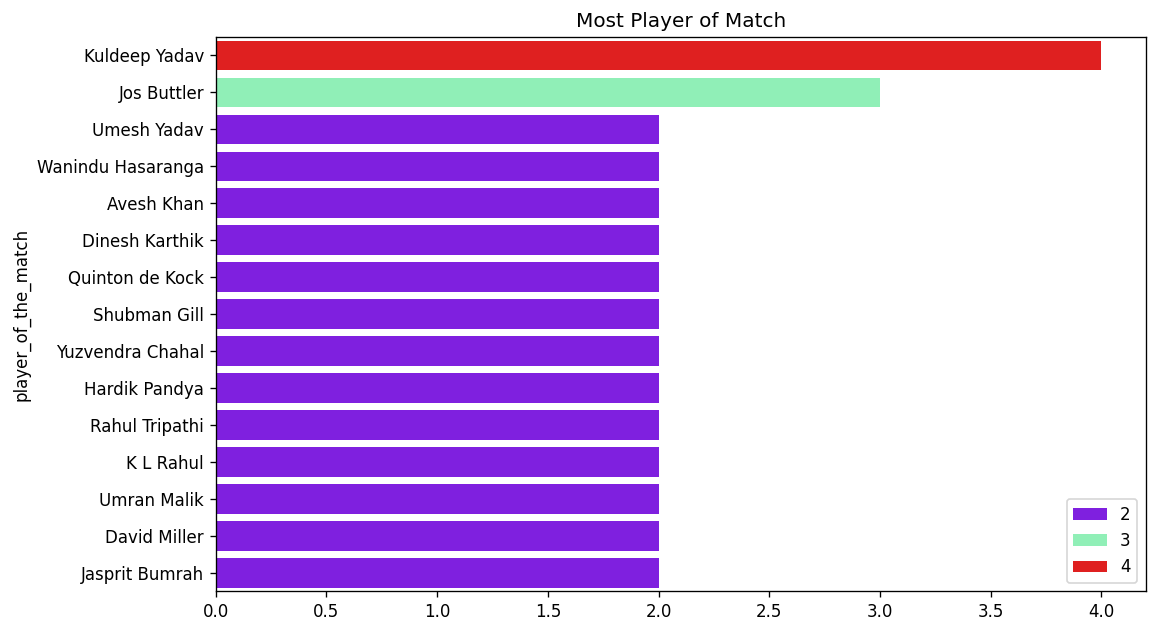

In [329]:
print(df['player_of_the_match'].value_counts().index[0])
ss = df['player_of_the_match'].value_counts()
ss=ss[ss>1]
fig= plt.figure(figsize=[10,6],dpi=120)

sns.barplot(y=ss.index,x=ss.values,palette="rainbow",hue=ss.values)
plt.title("Most Player of Match")
plt.show()


## **5.Top scorers**

In [330]:
tops = df.nlargest(10,"highscore")[["top_scorer","highscore"]]
tops

,top_scorer,highscore
65,Quinton de Kock,140
33,Jos Buttler,116
71,Rajat Patidar,112
72,Jos Buttler,106
25,KL Rahul,103
29,Jos Buttler,103
36,KL Rahul,103
8,Jos Buttler,100
45,Ruturaj Gaikwad,99
15,Shubman Gill,96


Text(0.5, 1.0, 'Top Innings')

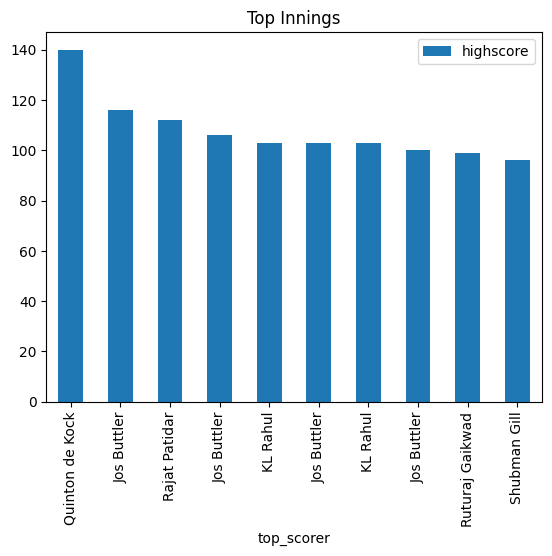

In [331]:
tops.plot(kind ='bar',x='top_scorer',y='highscore')
plt.title("Top Innings")

## **6.Best Bowling**

In [279]:
bowl = df[['best_bowling','best_bowling_figure']]
def ext(data) :
    return int(data[0])
bowl['most_wick']=bowl['best_bowling_figure'].apply(ext)
def ext2(data) :
    val=""
    for i in range(3,len(data)):
        val =val+data[i]
    return int(val)
bowl['most_run_conceedded']=bowl['best_bowling_figure'].apply(ext2)
bowl.head()


,best_bowling,best_bowling_figure,most_wick,most_run_conceedded
0,Dwayne Bravo,3--20,3,20
1,Kuldeep Yadav,3--18,3,18
2,Mohammed Siraj,2--59,2,59
3,Mohammed Shami,3--25,3,25
4,Yuzvendra Chahal,3--22,3,22


In [280]:
final = bowl.nlargest(10,'most_wick')
final.sort_values(by=['most_wick','most_run_conceedded'],ascending=[False,True],inplace=True)
final['best_bowling']=final['best_bowling']+" ("+final['best_bowling_figure'] + ")"


<Axes: xlabel='most_wick', ylabel='best_bowling'>

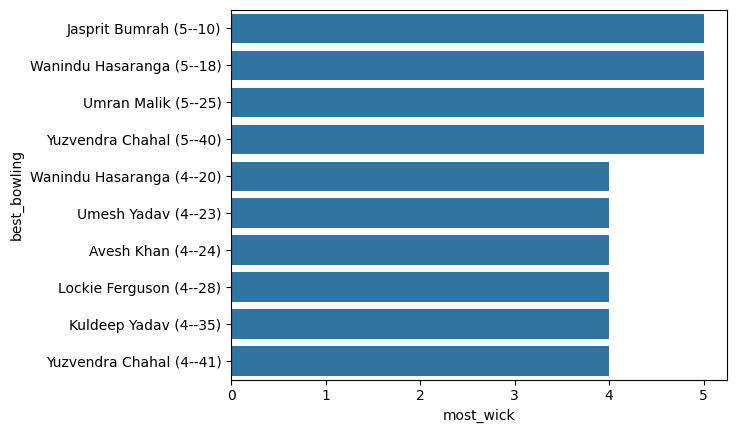

In [281]:
sns.barplot(final,y='best_bowling',x='most_wick')

## **7.Most Match Played By Venue**

In [282]:
df["venue"].value_counts()

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

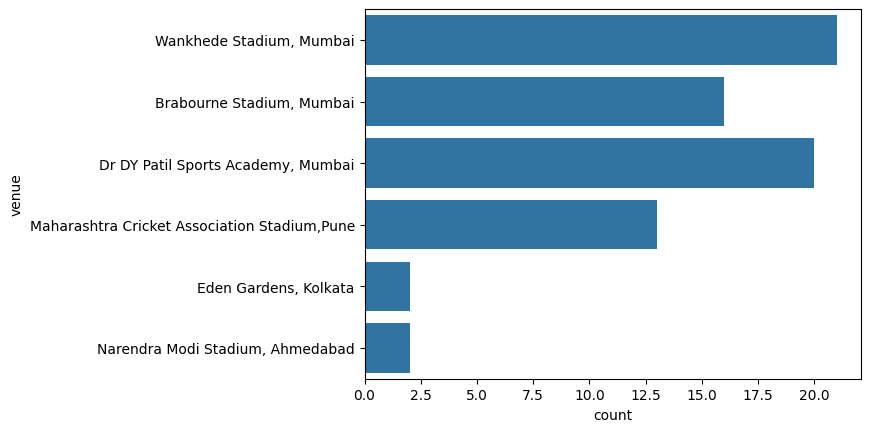

In [108]:
sns.countplot(df,y="venue")
plt.show()

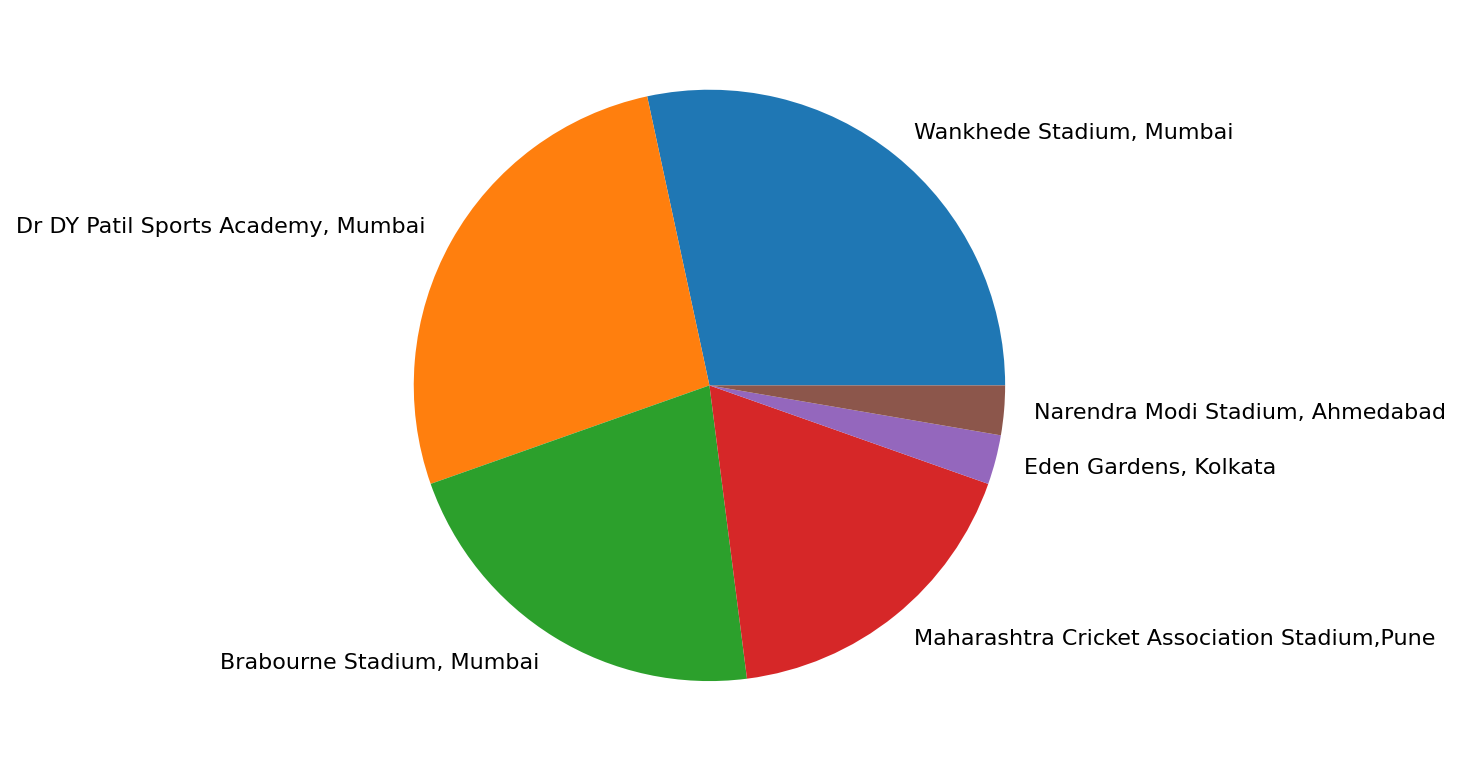

In [284]:
plt.figure(figsize=(8, 6),dpi=160)
plt.pie(df["venue"].value_counts(),labels=df["venue"].value_counts().index)
plt.show()

## **8.Who won the highest margin by runs**

In [295]:
df[df["won_by"]=="Runs"].nlargest(1,"margin")[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


(40.0, 100.0)

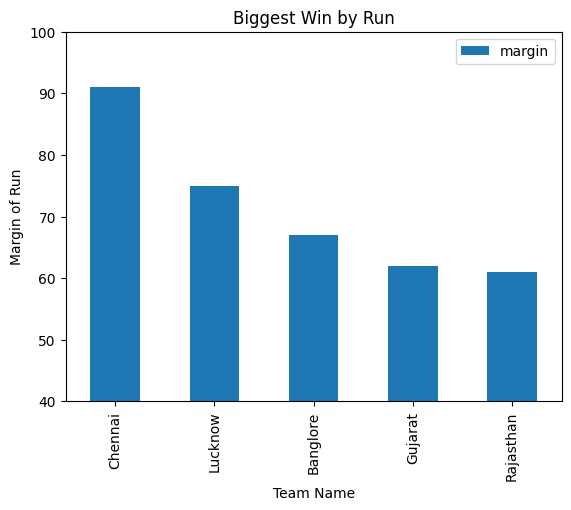

In [72]:
won_by= df[df["won_by"]=="Runs"].nlargest(5,"margin")[["match_winner","margin"]]
won_by.plot(kind="bar",x="match_winner",y="margin")
plt.xlabel("Team Name")
plt.ylabel("Margin of Run")
plt.title("Biggest Win by Run")
plt.ylim(40,100)



## **8. Highest First Innings Score**

In [5]:
## Feature extraction of team that bat first and bat second
cond1= ((df["toss_winner"]==df["team1"])&(df["toss_decision"]=="bat"))


cond2= ((df["toss_winner"]==df["team2"])&(df["toss_decision"]=="Field"))

df["bat_first"]=np.where(cond1|cond2,df["team1"],df["team2"])
df["bat_second"]=np.where(df["team1"]==df["bat_first"],df["team2"],df["team1"])

In [50]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,bat_first,bat_second
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,Chennai,Kolkata
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,Mumbai,Delhi
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,Banglore,Punjab
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,Lucknow,Gujarat
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,Rajasthan,Hyderabad


In [19]:
highest_1st_inns = df.nlargest(8,"first_ings_score")[["bat_first","match_winner","team1","team2","first_ings_score"]]
highest_1st_inns["match_looser"] = np.where(highest_1st_inns["match_winner"]==highest_1st_inns["team1"],highest_1st_inns["team2"],highest_1st_inns["team1"])
highest_1st_inns["MATCH"]=highest_1st_inns["team1"]+" vs "+highest_1st_inns["team2"]
highest_1st_inns["Result"]=np.where(highest_1st_inns["bat_first"]==highest_1st_inns["match_winner"],"Defended","Chased")
highest_1st_inns.drop(["team1","team2"],axis=1,inplace=True)

In [20]:
highest_1st_inns

,bat_first,match_winner,first_ings_score,match_looser,MATCH,Result
33,Rajasthan,Rajasthan,222,Delhi,Delhi vs Rajasthan,Defended
29,Rajasthan,Rajasthan,217,Kolkata,Kolkata vs Rajasthan,Defended
21,Chennai,Chennai,216,Banglore,Banglore vs Chennai,Defended
18,Delhi,Delhi,215,Kolkata,Delhi vs Kolkata,Defended
4,Rajasthan,Rajasthan,210,Hyderabad,Hyderabad vs Rajasthan,Defended
6,Chennai,Lucknow,210,Chennai,Chennai vs Lucknow,Chased
65,Lucknow,Lucknow,210,Kolkata,Kolkata vs Lucknow,Defended
59,Punjab,Punjab,209,Banglore,Banglore vs Punjab,Defended


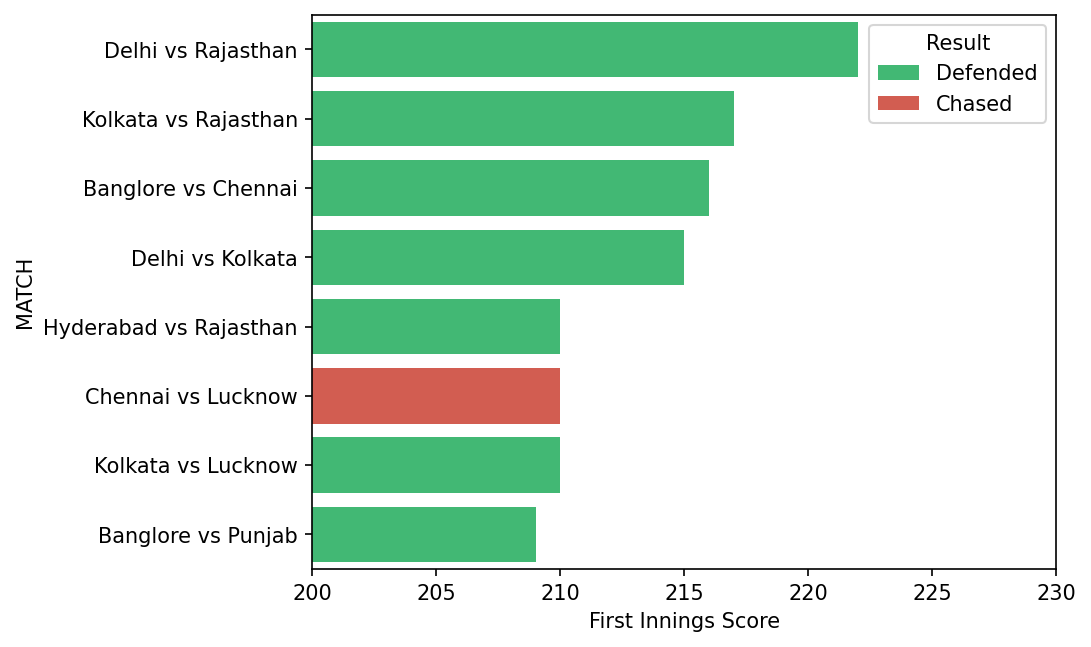

In [85]:
plt.figure(dpi=150)
sns.barplot(highest_1st_inns,x="first_ings_score",y="MATCH",hue="Result",palette={'Defended': '#2ecc71', 'Chased': '#e74c3c'})
plt.xlim(200, 230)
plt.xlabel("First Innings Score")
plt.show()

## **9. Highest 2nd Innings Score**

In [106]:
highest_2nd_innings =df.nlargest(8,'second_ings_score')[['second_ings_score','bat_first','bat_second','match_winner','first_ings_score']]
highest_2nd_innings["MATCH"]=highest_2nd_innings['bat_first'] + ' vs ' + highest_2nd_innings['bat_second']
highest_2nd_innings['Result']=np.where(highest_2nd_innings['bat_second']==highest_2nd_innings['match_winner'],"Won","Lost")
highest_2nd_innings['MATCH_TEAM'] = (
    highest_2nd_innings['MATCH'] + " (" + highest_2nd_innings['bat_second'] + ")"
)
highest_2nd_innings

,second_ings_score,bat_first,bat_second,match_winner,first_ings_score,MATCH,Result,MATCH_TEAM
6,211,Chennai,Lucknow,Lucknow,210,Chennai vs Lucknow,Won,Chennai vs Lucknow (Lucknow)
29,210,Rajasthan,Kolkata,Rajasthan,217,Rajasthan vs Kolkata,Lost,Rajasthan vs Kolkata (Kolkata)
2,208,Banglore,Punjab,Punjab,205,Banglore vs Punjab,Won,Banglore vs Punjab (Punjab)
65,208,Lucknow,Kolkata,Lucknow,210,Lucknow vs Kolkata,Lost,Lucknow vs Kolkata (Kolkata)
33,207,Rajasthan,Delhi,Rajasthan,222,Rajasthan vs Delhi,Lost,Rajasthan vs Delhi (Delhi)
39,199,Hyderabad,Gujarat,Gujarat,195,Hyderabad vs Gujarat,Won,Hyderabad vs Gujarat (Gujarat)
21,193,Chennai,Banglore,Chennai,216,Chennai vs Banglore,Lost,Chennai vs Banglore (Banglore)
71,193,Banglore,Lucknow,Banglore,207,Banglore vs Lucknow,Lost,Banglore vs Lucknow (Lucknow)


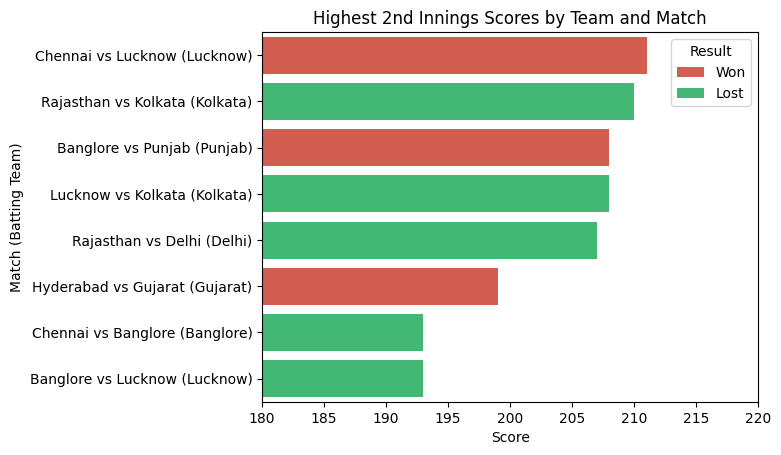

In [107]:
sns.barplot(
    data=highest_2nd_innings,
    x="second_ings_score",
    y="MATCH_TEAM", 
    hue="Result",
    palette={'Lost': '#2ecc71', 'Won': '#e74c3c'},


)

plt.title("Highest 2nd Innings Scores by Team and Match")
plt.xlabel("Score")
plt.ylabel("Match (Batting Team)")
plt.xlim(180,220)
plt.show()

In [35]:
by_venue=df[['first_ings_score','venue']]

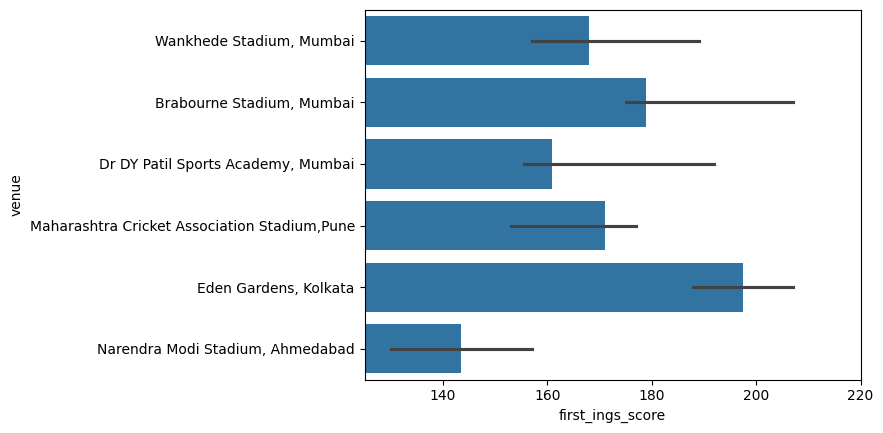

In [73]:
sns.barplot(by_venue,x='first_ings_score',y='venue',estimator='median')
plt.xlim(125,220)

plt.show()

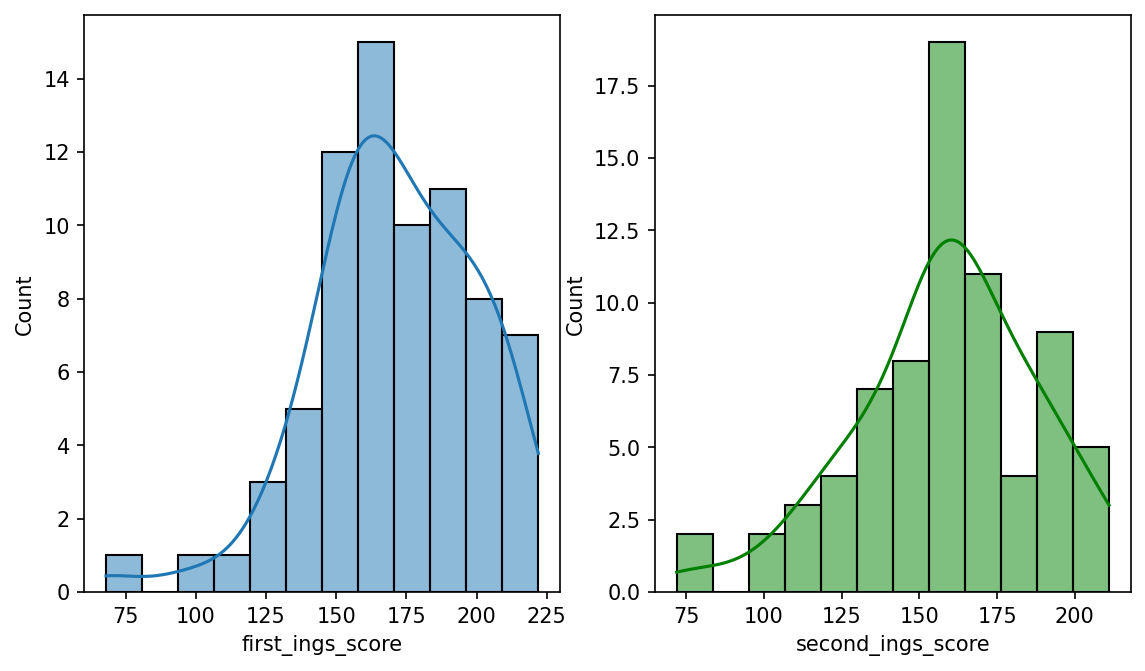

In [101]:
fig = plt.figure(figsize=[9,5],dpi=150)
plt.subplot(1,2,1)
sns.histplot(df,x='first_ings_score',bins=12,kde="True")
plt.subplot(1,2,2)
sns.histplot(df,x='second_ings_score',bins=12,kde="True",color="green")
plt.show()

<Axes: >

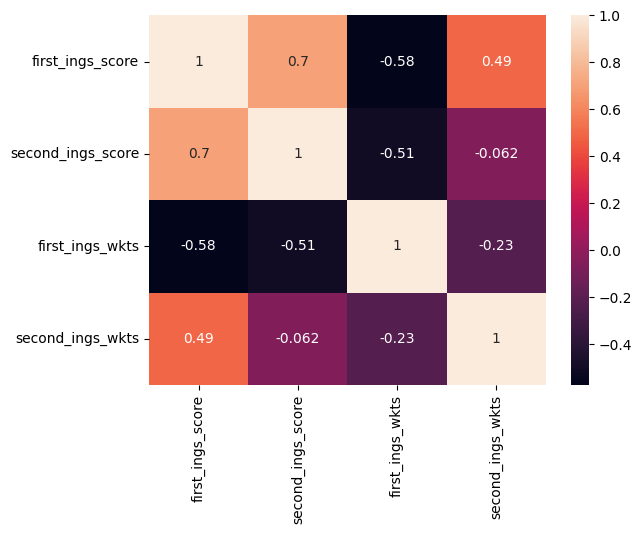

In [118]:
my_corr = df[['first_ings_score','second_ings_score','first_ings_wkts','second_ings_wkts']].corr()

sns.heatmap(my_corr,annot=True)

<Axes: xlabel='second_ings_score', ylabel='second_ings_score'>

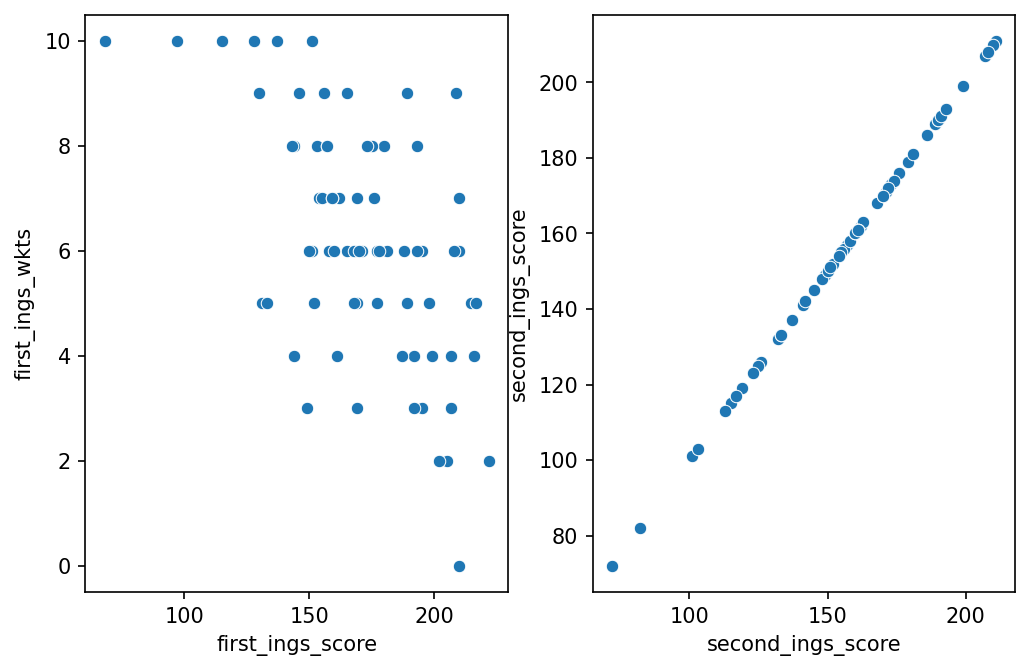

In [131]:
plt.figure(figsize=[8,5],dpi=150)
plt.subplot(1,2,1)
sns.scatterplot(df,y='first_ings_wkts',x='first_ings_score')
plt.subplot(1,2,2)

sns.scatterplot(df,y='second_ings_score',x='second_ings_score')
